# 1. Joint ST-INR：单一时空 Fourier-feature MLP

空间坐标 `(x,z)` 与全局时间坐标 `t` 分别做确定性 Fourier 编码，再拼接后输入同一个 MLP，直接表示 `log ρ(x,z,t)`。本实验不加显式空间或时间正则，用网络本身的表示偏置检验时间恢复能力。

输出目录：`result/2_inversion/0_flat_model/1`。


## 1. 环境与 GPU 检查


In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("ADTLERT_ENABLE_FLOAT64", "1")

cwd = Path.cwd().resolve()
root = next(path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists())
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.set_default_dtype(torch.float64)  # after adtlert fixed FLOAT_DTYPE at import
torch.set_float32_matmul_precision("high")

from adtlert.inr import (
    INRConfig,
    Optimization,
    Progressive,
    Windows,
    fit_timelapse_inr,
)
from example.timelapse_inr_experiment import (
    INRSnapshotRecorder,
    build_inr_forward,
    load_flat_timelapse_data,
    make_global_coordinates,
    plot_inr_recovery,
    save_inr_result,
)

forward_dir = root / "result/1_forward/0_flat_model"
truth_dir = root / "data/test_model/0_flat_model"
assert torch.cuda.is_available(), (
    "本 notebook 强制要求 CUDA，但 torch.cuda.is_available() 为 False"
)
print("project root:", root)
print("GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))

project root: /home/luffy/projects/DeepERT
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. 固定实验设置

三种 INR 共用相同网格、误差模型、初始电阻率、边界、初始学习率 `1e-3` 和最多 1000 轮优化；停止条件关闭。每 100 轮保存一次完整时移电阻率快照。不同策略的单轮计算量可以不同，运行时间仅作为实际计算成本参考。


In [2]:
method_label = "Joint ST-INR"
output_dir = root / "result/2_inversion/0_flat_model/1"
output_dir.mkdir(parents=True, exist_ok=True)

settings = {
    "random_seed": 20261001,
    "max_iterations": 1000,
    "learning_rate": 1.0e-3,
    "optimizer": "adamw",
    "scheduler": "multistep",
    "learning_rate_milestones": (400, 750),
    "weight_decay": 1.0e-6,
    "progressive_full_iteration": 200,
    "snapshot_interval": 100,
    "time_window_size": None,
    "time_window_step": 1,
    "full_evaluation_interval": 1,
    "mesh_quality": 34.0,
    "mesh_max_cell_area": 100.0,
    "mesh_smoothing_iterations": 10,
    "forward_refinement": "native",
    "normal_field_cache_max_entries": 49,
}
print("output:", output_dir)
settings

output: /home/luffy/projects/DeepERT/result/2_inversion/0_flat_model/1


{'random_seed': 20261001,
 'max_iterations': 1000,
 'learning_rate': 0.001,
 'optimizer': 'adamw',
 'scheduler': 'multistep',
 'learning_rate_milestones': (400, 750),
 'weight_decay': 1e-06,
 'progressive_full_iteration': 200,
 'snapshot_interval': 100,
 'time_window_size': None,
 'time_window_step': 1,
 'full_evaluation_interval': 1,
 'mesh_quality': 34.0,
 'mesh_max_cell_area': 100.0,
 'mesh_smoothing_iterations': 10,
 'forward_refinement': 'native',
 'linear_solver_backend': 'cudss',
 'normal_field_cache_max_entries': 49}

## 3. 读取49个时刻的 DAT 观测与合成真值


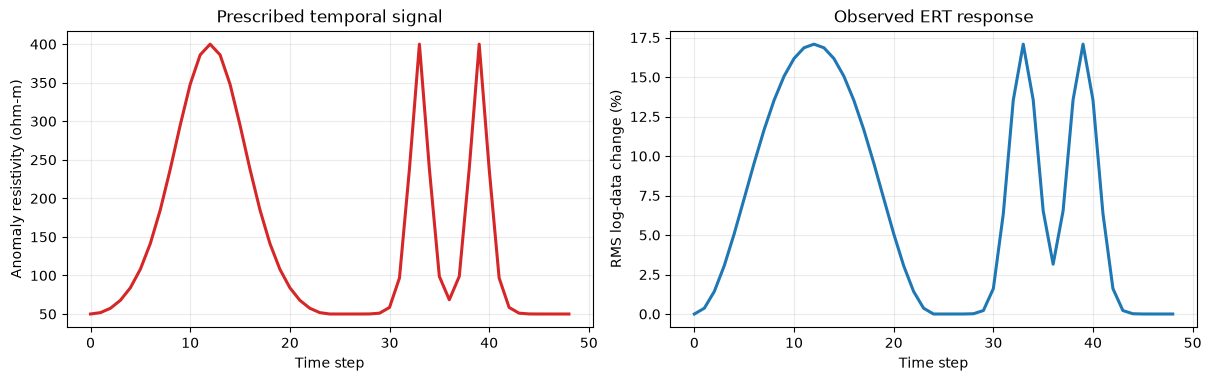

timesteps: 49
observed rhoa: (49, 360)
measurements per timestep: 360
median relative error: 0.03


In [3]:
data = load_flat_timelapse_data(forward_dir, truth_dir)
log_change_rms = 100.0 * np.sqrt(
    np.mean(np.log(data.observed_rhoa / data.observed_rhoa[0]) ** 2, axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), constrained_layout=True)
axes[0].plot(data.steps, data.truth_anomaly_curve, color="#d62728", linewidth=2.2)
axes[0].set(
    xlabel="Time step",
    ylabel="Anomaly resistivity (ohm-m)",
    title="Prescribed temporal signal",
)
axes[0].grid(alpha=0.25)
axes[1].plot(data.steps, log_change_rms, color="#1f77b4", linewidth=2.2)
axes[1].set(
    xlabel="Time step", ylabel="RMS log-data change (%)", title="Observed ERT response"
)
axes[1].grid(alpha=0.25)
plt.show()

print("timesteps:", data.steps.size)
print("observed rhoa:", data.observed_rhoa.shape)
print("measurements per timestep:", data.measurements.shape[0])
print("median relative error:", float(np.median(data.err)))

## 4. 建立独立反演网格与全局 `(x,z,t)` 坐标

反演参数网格仅由电极与测量装置生成，不使用合成真值的规则网格。时间始终按完整49时刻归一化。


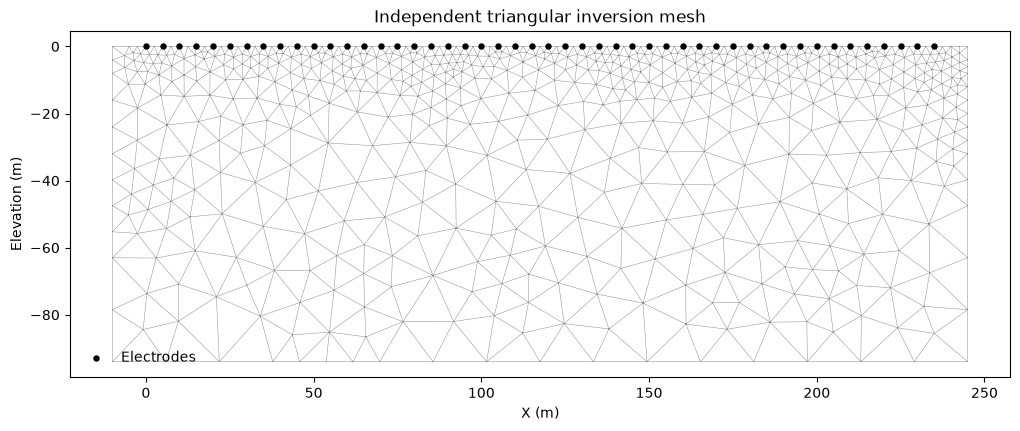

coordinates: (49, 1126, 3) range: -1.0 to 1.0
inversion cells: 1126
forward cells: 1768
truth-grid cells: 2256


In [4]:
bundle = build_inr_forward(
    data,
    mesh_quality=settings["mesh_quality"],
    mesh_max_cell_area=settings["mesh_max_cell_area"],
    mesh_smoothing_iterations=settings["mesh_smoothing_iterations"],
    forward_refinement=settings["forward_refinement"],
    normal_field_cache_max_entries=settings["normal_field_cache_max_entries"],
)
coordinates, coordinate_center, coordinate_scale = make_global_coordinates(
    bundle, data.steps
)

mesh_nodes = np.asarray(bundle.case.mesh.nodes, dtype=float)
mesh_cells = np.asarray(bundle.case.mesh.cells, dtype=np.int32)
fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
ax.triplot(mesh_nodes[:, 0], mesh_nodes[:, 1], mesh_cells, color="0.55", linewidth=0.35)
ax.scatter(data.elec_x, data.elec_z, s=13, c="black", zorder=3, label="Electrodes")
ax.set(
    xlabel="X (m)",
    ylabel="Elevation (m)",
    title="Independent triangular inversion mesh",
)
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False)
plt.show()

print(
    "coordinates:",
    coordinates.shape,
    "range:",
    float(coordinates.min()),
    "to",
    float(coordinates.max()),
)
print("inversion cells:", bundle.case.mesh.cell_count)
print("forward cells:", bundle.forward_mesh.cell_count)
print("truth-grid cells:", data.truth_models.shape[1] * data.truth_models.shape[2])

## 5. 构建 INR

网络输出有界的对数电阻率，并通过零初始化输出层严格从100 Ω·m均匀模型开始。


In [5]:
from adtlert.inr import JointSpatioTemporalINR

torch.manual_seed(settings["random_seed"])
network = JointSpatioTemporalINR(
    spatial_levels=5,
    temporal_levels=4,
    hidden_width=64,
    hidden_layers=3,
    initial_resistivity=100.0,
    resistivity_bounds=(10.0, 1000.0),
)

parameter_count = sum(parameter.numel() for parameter in network.parameters())
with torch.no_grad():
    initial_log_model = network.to(device="cuda", dtype=torch.float32)(
        torch.as_tensor(coordinates, device="cuda")
    )
initial_rho = initial_log_model.exp()
assert torch.allclose(initial_rho, torch.full_like(initial_rho, 100.0), atol=1.0e-3)
print(type(network).__name__)
print("trainable parameters:", parameter_count)
print(
    "initial resistivity:",
    float(initial_rho.min()),
    "to",
    float(initial_rho.max()),
    "ohm-m",
)
del initial_log_model, initial_rho

JointSpatioTemporalINR
trainable parameters: 10433
initial resistivity: 100.0 to 100.0 ohm-m


## 6. 配置进度输出与模型快照


In [6]:
snapshot_recorder = INRSnapshotRecorder(output_dir / "snapshots")


def report_progress(event):
    snapshot_path = snapshot_recorder(event)
    if snapshot_path is not None:
        print(f"saved snapshot: {snapshot_path.name}")
        return
    if event.get("event") != "iteration":
        return
    full_text = (
        ""
        if event.get("full_chi2") is None
        else f", full chi2={event['full_chi2']:.6g}"
    )
    window_text = (
        ""
        if event.get("window_start") is None
        else f", window=[{event['window_start']}:{event['window_stop']}]"
    )
    print(
        f"iter={event['iteration']:4d}, train chi2={event['chi2']:.6g}{full_text}{window_text}, "
        f"lr={event['learning_rate']:.3g}"
    )

## 7. GPU ERT 物理约束反演

网络在 CUDA 上运行；ERT 线性求解器必须实际启用 cuDSS，否则立即报错。


In [7]:
config = INRConfig(
    max_iterations=settings["max_iterations"],
    target_chi2=None,
    device="cuda",
    log_every=10,
    prepare_solver=True,
    snapshot_interval=settings["snapshot_interval"],
    optimization=Optimization(
        optimizer=settings["optimizer"],
        learning_rate=settings["learning_rate"],
        weight_decay=settings["weight_decay"],
        gradient_clip_norm=10.0,
        scheduler=settings["scheduler"],
        learning_rate_milestones=settings["learning_rate_milestones"],
    ),
    progressive=Progressive(
        full_iteration=settings["progressive_full_iteration"],
        spatial_start_levels=2,
        temporal_start_levels=1,
    ),
    windows=Windows(
        size=settings["time_window_size"],
        step=settings["time_window_step"],
        full_evaluation_interval=settings["full_evaluation_interval"],
        alternate_direction=True,
    ),
    progress_callback=report_progress,
)

try:
    result = fit_timelapse_inr(
        bundle.forward,
        network,
        coordinates,
        data.observed_rhoa,
        data.data_std,
        config=config,
    )
finally:
    bundle.forward.close()

print(json.dumps(result.gpu_report, indent=2))
print(f"best iter={result.best_iteration}, chi2={result.best_chi2:.6g}")
print(f"time={result.timing.elapsed:.3f} s, stop={result.stop_reason}")
print(
    "physics forward/VJP timesteps:",
    result.timing.forward_timesteps,
    result.timing.vjp_timesteps,
)

iter=   0, train chi2=4.79141, full chi2=4.79141, lr=0.001
iter=  10, train chi2=4.64741, full chi2=4.64741, lr=0.001
iter=  20, train chi2=4.39584, full chi2=4.39584, lr=0.001
iter=  30, train chi2=3.87522, full chi2=3.87522, lr=0.001
iter=  40, train chi2=2.57021, full chi2=2.57021, lr=0.001
iter=  50, train chi2=2.30669, full chi2=2.30669, lr=0.001
iter=  60, train chi2=2.0369, full chi2=2.0369, lr=0.001
iter=  70, train chi2=1.90967, full chi2=1.90967, lr=0.001
iter=  80, train chi2=1.7246, full chi2=1.7246, lr=0.001
iter=  90, train chi2=1.51597, full chi2=1.51597, lr=0.001
iter= 100, train chi2=1.3061, full chi2=1.3061, lr=0.001
saved snapshot: resistivity_iter_0100.npy
iter= 110, train chi2=1.12908, full chi2=1.12908, lr=0.001
iter= 120, train chi2=0.938778, full chi2=0.938778, lr=0.001
iter= 130, train chi2=0.81958, full chi2=0.81958, lr=0.001
iter= 140, train chi2=0.748148, full chi2=0.748148, lr=0.001
iter= 150, train chi2=0.615279, full chi2=0.615279, lr=0.001
iter= 160, tra

## 8. 保存统一格式结果与快照索引


In [8]:
summary = save_inr_result(
    output_dir,
    method=method_label,
    data=data,
    bundle=bundle,
    network=network,
    config=config,
    result=result,
    coordinate_center=coordinate_center,
    coordinate_scale=coordinate_scale,
)
snapshot_recorder.save_summary()
summary

{'engine': 'ADTLERT matrix-free GPU INR',
 'method': 'Joint ST-INR',
 'network_class': 'JointSpatioTemporalINR',
 'network_configuration': {'input_dimensions': 3,
  'spatial_levels': 5,
  'temporal_levels': 4,
  'hidden_width': 64,
  'hidden_layers': 3,
  'initial_resistivity': 100.0,
  'resistivity_bounds': (10.0, 1000.0)},
 'network_parameter_count': 10433,
 'n_timesteps': 49,
 'n_measurements_per_timestep': 360,
 'n_inversion_cells': 1126,
 'n_forward_cells': 1768,
 'mesh_is_independent_from_synthetic_grid': True,
 'initial_resistivity_ohm_m': 100.0,
 'explicit_spatial_regularization': 0.0,
 'explicit_temporal_regularization': 0.0,
 'config': {'max_iterations': 1000,
  'learning_rate': 0.001,
  'optimizer': 'adamw',
  'scheduler': 'multistep',
  'learning_rate_milestones': (400, 750),
  'target_chi2': None,
  'device': 'cuda',
  'require_cuda': True,
  'gradient_clip_norm': 10.0,
  'weight_decay': 1e-06,
  'plateau_patience': 20,
  'plateau_factor': 0.5,
  'minimum_learning_rate': 1

## 9. 查看优化过程


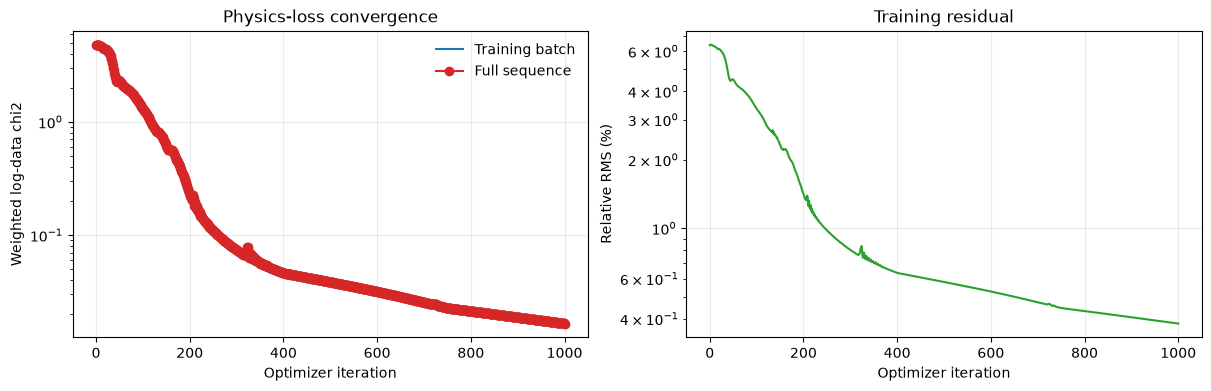

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
axes[0].plot(
    np.arange(result.history.chi2.size),
    result.history.chi2,
    color="#1f77b4",
    label="Training batch",
)
axes[0].plot(
    result.history.full_iterations,
    result.history.full_chi2,
    "o-",
    color="#d62728",
    label="Full sequence",
)
axes[0].set(
    xlabel="Optimizer iteration",
    ylabel="Weighted log-data chi2",
    title="Physics-loss convergence",
)
axes[0].set_yscale("log")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)
axes[1].plot(np.arange(result.history.rms.size), result.history.rms, color="#2ca02c")
axes[1].set(
    xlabel="Optimizer iteration", ylabel="Relative RMS (%)", title="Training residual"
)
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)
plt.show()

## 10. 真值、反演快照与异常体时间曲线

所有方法固定使用30–600 Ω·m色标以及相同的六个时刻。


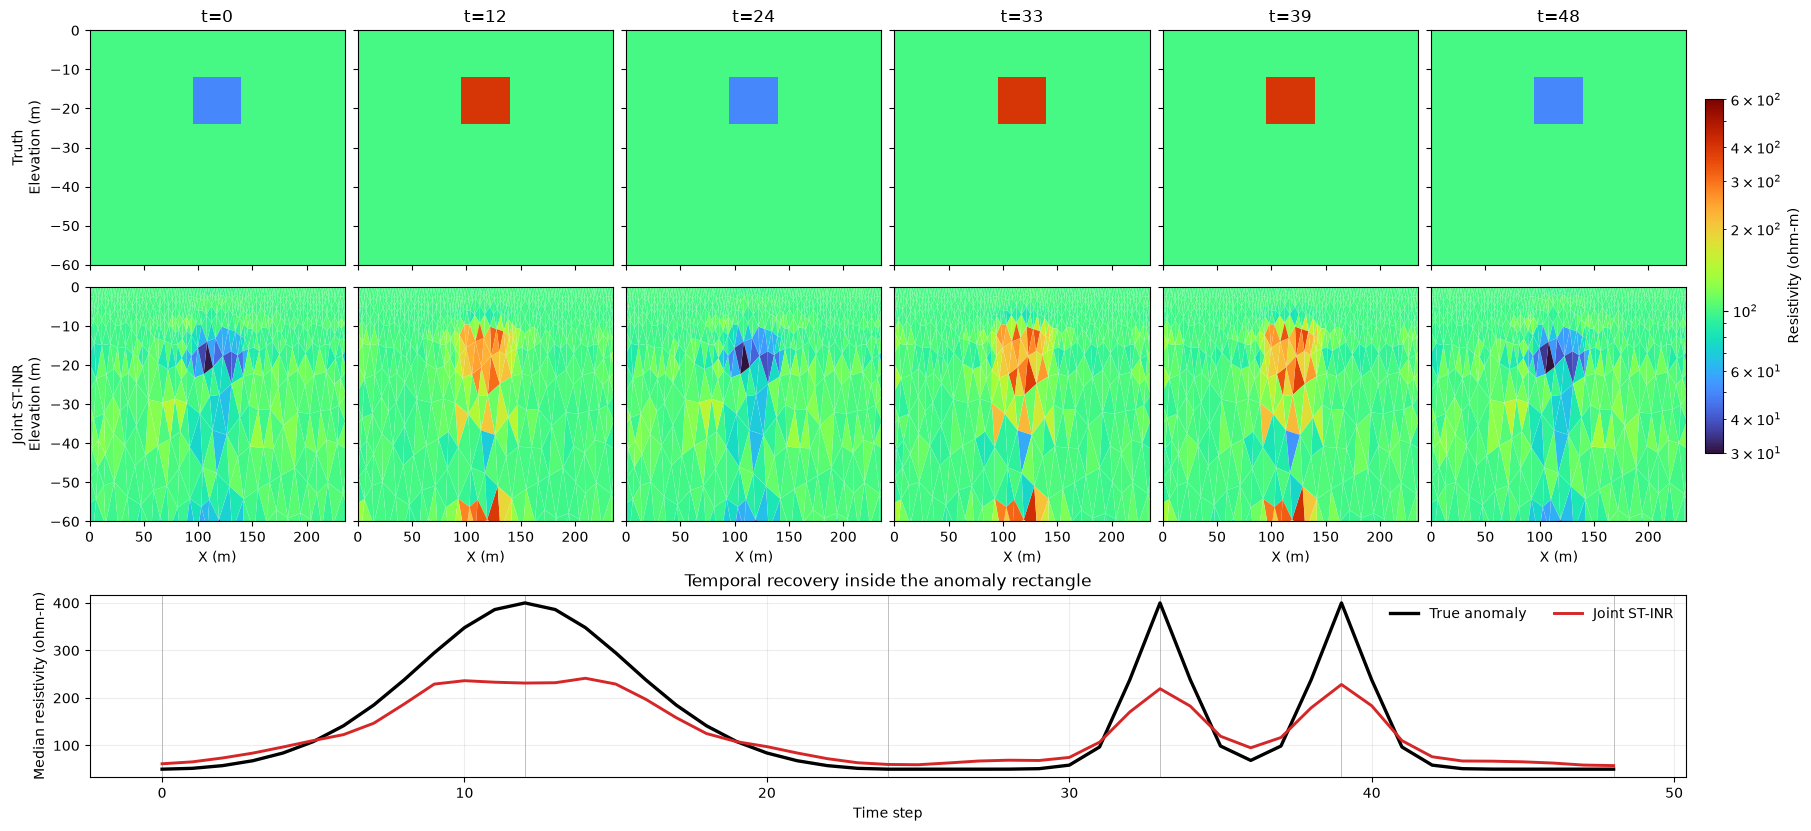

In [10]:
inverted_anomaly_curve = plot_inr_recovery(
    output_dir,
    method_label=method_label,
    data=data,
    bundle=bundle,
    result=result,
)

## 11. 输出文件


In [11]:
for path in sorted(output_dir.iterdir()):
    print(f"{path.name:36s} {path.stat().st_size:>12d} bytes")

chi2_by_time.npy                              520 bytes
coordinate_transform.npz                      414 bytes
final_log_models.npy                       441520 bytes
final_models.npy                           441520 bytes
inversion_summary.json                       2206 bytes
model_and_temporal_recovery.png           1117373 bytes
network.pt                                  47795 bytes
predicted_rhoa.npy                         141248 bytes
snapshots                                    4096 bytes
steps.npy                                     324 bytes
timelapse_inversion_mesh.npz               115920 bytes
training_history.npz                        17468 bytes
used_data_files.txt                          4802 bytes
